# Part 3, Task 6.4/6.5 — Monitoring and Alerting Simulation (visual companion)

`monitoring/monitor.py` runs two drift checks (feature distribution via
KS test, and prediction error) and writes a markdown report. This notebook
calls the exact same functions — no logic is duplicated here — and adds
charts on top of the tables.

In [1]:
import sys
from pathlib import Path

for _candidate in (Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts"):
    if (_candidate / "common.py").exists():
        sys.path.insert(0, str(_candidate))
        break
for _candidate in (Path.cwd().parent / "monitoring", Path.cwd() / "monitoring"):
    if (_candidate / "monitor.py").exists():
        sys.path.insert(0, str(_candidate))
        break

import matplotlib.pyplot as plt
import pandas as pd

from common import chronological_split, get_full_dataset
from monitor import (
    ERROR_DRIFT_ALERT_THRESHOLD,
    KS_ALERT_THRESHOLD,
    check_feature_drift,
    check_prediction_error_drift,
    demo_alert_scenario,
)

pd.set_option("display.max_columns", None)
FIGURES_DIR = Path.cwd() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

df = get_full_dataset()
train_df, test_df = chronological_split(df)

2026-09-15 12:28:57,970 | INFO     | common | Loaded Part 2 featured dataset from /home/claude/smart-city-traffic-capstone/part2_python/featured_traffic_data.csv: 40575 rows, 34 columns


2026-09-15 12:28:58,035 | INFO     | common | Added proxy 'high_risk' label: 3090 high-risk hours out of 40575 (7.6%)


2026-09-15 12:28:58,042 | INFO     | common | Chronological train/test split: train=32460 rows (2012-10-02 09:00:00 to 2017-10-26 17:00:00), test=8115 rows (2017-10-26 18:00:00 to 2018-09-30 23:00:00)


## Feature distribution drift (train vs. most recent period, KS test)

Bars past the red alert-threshold line would mean that feature's
distribution has shifted meaningfully since training.

In [2]:
drift_df = check_feature_drift(train_df, test_df)
drift_df

,feature,ks_statistic,p_value,status
6,weather_Clouds,0.074214,1.530170e-31,PASS
16,is_severe_weather,0.041097,5.782765e-10,PASS
13,weather_Snow,0.032779,1.704520e-06,PASS
5,weather_Clear,0.027110,1.406854e-04,PASS
17,is_low_visibility,0.017745,3.313175e-02,PASS
10,weather_Mist,0.012107,2.948137e-01,PASS
11,weather_Rain,0.010382,4.828467e-01,PASS
15,weather_Thunderstorm,0.008349,7.527733e-01,PASS
1,hour_cos,0.005823,9.794592e-01,PASS
9,weather_Haze,0.005638,9.853294e-01,PASS


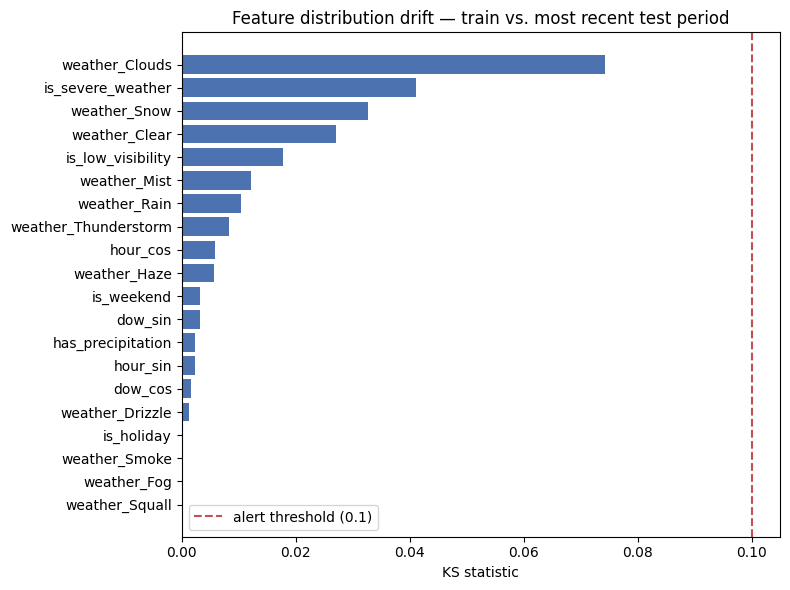

In [3]:
colors = ["#C44E52" if s == "ALERT" else "#4C72B0" for s in drift_df["status"]]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(drift_df["feature"], drift_df["ks_statistic"], color=colors)
ax.axvline(KS_ALERT_THRESHOLD, color="#C44E52", linestyle="--", label=f"alert threshold ({KS_ALERT_THRESHOLD})")
ax.set_xlabel("KS statistic")
ax.set_title("Feature distribution drift — train vs. most recent test period")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitoring_feature_drift.png", dpi=120)
plt.show()

## Prediction error drift (regression model, first vs. second half of test period)

In [4]:
error_drift = check_prediction_error_drift(test_df)
error_drift

{'mae_first_half': 317.5715702457071,
 'mae_second_half': 239.11706436675874,
 'pct_change': -0.24704511747776298,
 'status': 'PASS'}

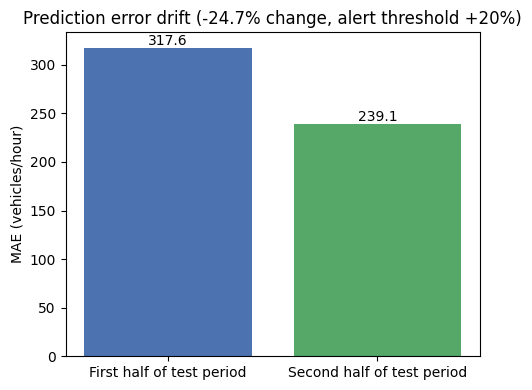

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["First half of test period", "Second half of test period"],
    [error_drift["mae_first_half"], error_drift["mae_second_half"]],
    color=["#4C72B0", "#C44E52" if error_drift["status"] == "ALERT" else "#55A868"],
)
ax.set_ylabel("MAE (vehicles/hour)")
ax.set_title(f"Prediction error drift ({error_drift['pct_change']*100:+.1f}% change, "
             f"alert threshold +{ERROR_DRIFT_ALERT_THRESHOLD*100:.0f}%)")
for bar, value in zip(bars, [error_drift["mae_first_half"], error_drift["mae_second_half"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 3, f"{value:.1f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitoring_error_drift.png", dpi=120)
plt.show()

## Appendix: ALERT-path demonstration (synthetic data)

The checks above legitimately come back PASS because the real test period
isn't actually drifted. To prove the alerting mechanism itself works, this
reruns the identical KS-test check against a synthetically perturbed copy
of the test set (severe-weather rate artificially inflated) — a deliberate
demonstration, not a claim about the real data.

In [6]:
print(demo_alert_scenario(train_df, test_df))


## Appendix: ALERT-path demonstration (synthetic data)

The monitoring run above came back PASS because the real test period isn't actually drifted. To demonstrate the alerting mechanism itself works, this section re-runs the identical KS-test check against a **synthetically perturbed** copy of the test set (severe-weather rate artificially inflated) — this is a deliberate demonstration, not a claim about the real data.

| feature              |   ks_statistic |   p_value | status   |
|:---------------------|---------------:|----------:|:---------|
| weather_Thunderstorm |         0.604  |         0 | ALERT    |
| is_severe_weather    |         0.5887 |         0 | ALERT    |
| weather_Clear        |         0.1846 |         0 | ALERT    |

**Result: 3 feature(s) correctly flagged as ALERT** under the synthetic drift, confirming the mechanism triggers as designed.
